# Aula 16 — Comprar vs Leasing: o VPL do lado do custo

**Semana 8 | Aula de 50 min | Referências: McKinney, *Python for Data Analysis* (2012), cap. 11 (*Financial and Economic Data Applications*); Jansen, *ML for Algorithmic Trading* (2ª ed.), cap. 5 (taxa livre de risco como base da taxa de desconto).**

## 🎯 Objetivos de aprendizagem

Ao final desta aula você será capaz de:

- Montar o **fluxo de caixa pós-impostos** de três formas de usar um mesmo ativo (compra à vista, financiamento, leasing operacional);
- Quantificar o **escudo fiscal** da depreciação e da dedutibilidade de juros e parcelas de leasing;
- Comparar alternativas de **custo** pelo menor VPL (menor valor presente líquido de desembolsos) — e explicar por que "menor VPL de custo" vence "menor parcela";
- Calcular o **break-even da taxa** de contrato que inverte a decisão compra × financiamento;
- Entregar um **relatório sintético** (DataFrame-resumo + recomendação) no formato que a consultoria OIKOS apresenta ao cliente.

## 1. Três portas para o mesmo caminhão

**Intuição econômica.** A OIKOS foi procurada por uma transportadora de grãos de
Morrinhos (GO): ela precisa de **um caminhão-caçamba de R$ 1,2 milhão** para a safra
de verão. O diretor já ouviu três propostas e está confuso — cada vendedor diz que
"a dele é a mais barata":

1. **Compra à vista** — R$ 1,2 mi hoje, o caminhão é da empresa, se deprecia em 10 anos;
2. **Financiamento** — 20% de entrada (R$ 240 mil) + 48 parcelas a 14% a.a., juros dedutíveis;
3. **Leasing operacional** — 36 parcelas de R$ 35 mil, sem entrada, opção de compra por R$ 700 mil no mês 36.

**O erro clássico do comitê**: comparar *parcela* (R$ 25.837,68 vs R$ 35.000 vs
"R$ 1,2 mi de uma vez"). Parcela ignora **impostos**: no Brasil, IRPJ+CSLL de 34%
devolve parte do custo na forma de **escudo fiscal** — e devolve **valores diferentes**
em cada caminho. A pergunta certa é: *"qual caminho deixa a empresa com mais caixa
em valor de hoje?"* — e isso é VPL, agora aplicado ao lado do **custo**.

## 2. O método: VPL de custos, não de receitas

Quando os três caminhos entregam **o mesmo serviço** (um caminhão rodando na safra),
a receita é idêntica e cancela dos dois lados. Comparamos só os desembolsos:

$$VPL\_custo = \sum_{t} \frac{Desembolso_t \; - \; Escudo_t}{(1+i)^t}$$

- $i$ = WACC = **13,9% a.a.** (o mesmo da Aula 15: Selic set/2026 13,9%, rf ≈ 11,9%,
  prêmio 4,5 p.p., dívida pós-IR 9,9% — escolha conservadora);
- $Escudo_t$ = gasto dedutível × **34%** (IRPJ + CSLL): depreciação, juros do financiamento, parcela do leasing;
- **Decisão**: menor VPL de custo vence. (Quando os horizontes diferem, anualizamos
  pelo **CAE** — custo anual equivalente — que veremos no relatório final.)

Regra fiscal que usaremos: **depreciação linear em 10 anos** (R$ 120.000/ano);
juros do financiamento e parcelas de leasing são **dedutíveis quando pagos**;
a depreciação do leasing é do arrendador, não da locatária.

In [1]:
# Setup — imports e padrões visuais usados na aula
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

def brl(x):
    """Formata um número como moeda brasileira: R$ 1.234,56."""
    return f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

np.random.seed(42)  # reprodutibilidade quando houver aleatoriedade
print("Setup concluído sem erros — ambiente operacional!")

Setup concluído sem erros — ambiente operacional!


In [2]:
# Setup do caso: ativo, imposto e taxa de desconto (comuns aos 3 cenários)
preco_ativo = 1_200_000        # caminhão-caçamba (R$)
t = 0.139                      # WACC — mesma régua da Aula 15 (Selic set/2026 13,9%)
ir = 0.34                      # IRPJ + CSLL combinados
dep_anual = preco_ativo / 10   # depreciação linear em 10 anos → R$ 120.000/ano

print(f"Ativo: {brl(preco_ativo)} | depreciação {brl(dep_anual)}/ano por 10 anos")
print(f"Escudo fiscal da depreciação: {brl(ir * dep_anual)} por ano (34% de {brl(dep_anual)})")

Ativo: R$ 1.200.000,00 | depreciação R$ 120.000,00/ano por 10 anos
Escudo fiscal da depreciação: R$ 40.800,00 por ano (34% de R$ 120.000,00)


## 3. Cenário A — compra à vista: desembolso hoje, escudo por 10 anos

Fluxo pós-imposto: **−R$ 1,2 mi no ano 0** e, nos anos 1–10, um *ganho fiscal* de
34% × R$ 120.000 = **R$ 40.800/ano** (a depreciação reduz o lucro tributável).

$$VPL_A = 1{.}200.000 - 40.800 \times AF(13{\%}, 10)$$

O fator de anuidade $AF(i,n) = \frac{1-(1+i)^{-n}}{i}$ vale o pacote de escudos —
mesma matemática da parcela Price, agora do lado do imposto.

In [3]:
# Cenário A: VPL de custo = preço - valor presente dos escudos da depreciação
def af(i, n):
    """Fator de anuidade: valor presente de R$ 1/ano por n anos a i% a.a."""
    return (1 - (1 + i) ** (-n)) / i

escudo_dep = ir * dep_anual                       # 40.800/ano, anos 1..10
pv_escudos_A = escudo_dep * af(t, 10)
vpl_A = preco_ativo - pv_escudos_A

print(f"AF(13,9%, 10 anos) = {af(t, 10):.4f}")
print(f"PV dos escudos de depreciação: {brl(pv_escudos_A)}")
print(f"VPL de custo — A (compra à vista): {brl(vpl_A)}")
print("Menos que R$ 1,2 mi: o imposto devolve ~R$ 214 mil em valor de hoje.")

AF(13,9%, 10 anos) = 5.2365
PV dos escudos de depreciação: R$ 213.650,69
VPL de custo — A (compra à vista): R$ 986.349,31
Menos que R$ 1,2 mi: o imposto devolve ~R$ 214 mil em valor de hoje.


## 4. Cenário B — financiamento: entrada + parcelas + juros que abatem imposto

Estrutura: **entrada 20%** (R$ 240 mil no mês 0) + **48 parcelas** Price a **14% a.a.**
sobre R$ 960 mil. Três peças de caixa:

1. Parcelas — descontadas na **taxa mensal equivalente ao WACC** ($1{,}0905\%$ a.m.);
2. **Juros dedutíveis** — cada parcela tem uma parte de juros; só ela escuda (34%);
3. Depreciação — o ativo é da empresa: escudo de R$ 40.800/ano **do ano 1 ao 10**,
   mesmo financiado.

O erro que derruba consultoria júnior: descontar as parcelas a 14% (a taxa do
contrato é o **juro do banco**, não o custo de capital da empresa — quem decide
é o WACC).

In [4]:
# Financiamento: entrada 20% + 48 parcelas Price a 14% a.a. (taxa de CONTRATO)
def pmt_price(pv, i_m, n):
    """Parcela Price: pv × i / (1 − (1+i)^−n)."""
    return pv * i_m / (1 - (1 + i_m) ** (-n))

fin_pv = 0.80 * preco_ativo          # R$ 960.000 financiados
entrada = 0.20 * preco_ativo         # R$ 240.000 no ato
i_contrato_aa = 0.14                 # 14% a.a. de contrato
i_fin = (1 + i_contrato_aa) ** (1 / 12) - 1     # 1,0979% a.m.
n_fin = 48

parcela_fin = pmt_price(fin_pv, i_fin, n_fin)
print(f"Entrada: {brl(entrada)} | financiando: {brl(fin_pv)}")
print(f"i mensal do contrato: {i_fin:.4%} → parcela: {brl(parcela_fin)}/mês × 48")

Entrada: R$ 240.000,00 | financiando: R$ 960.000,00
i mensal do contrato: 1.0979% → parcela: R$ 25.837,68/mês × 48


In [5]:
# Tabela do financiamento para separar JUROS (dedutível) de amortização (não dedutível)
linhas = []
saldo = fin_pv
for k in range(1, n_fin + 1):
    juros = saldo * i_fin
    amort = parcela_fin - juros
    saldo -= amort
    linhas.append((k, juros, amort, max(saldo, 0)))

fin = pd.DataFrame(linhas, columns=["mes", "juros", "amortizacao", "saldo"])
juros_por_ano = fin.groupby(fin["mes"].sub(1).floordiv(12) + 1)["juros"].sum()
print(f"Juros totais do contrato: {brl(fin['juros'].sum())}")
print("Juros por ano (R$):", {f"ano {a}": f"{j:,.0f}" for a, j in juros_por_ano.items()})
print("No ano 1, juros pagos =", brl(juros_por_ano.loc[1]),
      "→ escudo de", brl(0.34 * juros_por_ano.loc[1]), "só de juros.")

Juros totais do contrato: R$ 280.208,48
Juros por ano (R$): {'ano 1': '114,976', 'ano 2': '87,665', 'ano 3': '56,531', 'ano 4': '21,038'}
No ano 1, juros pagos = R$ 114.975,53 → escudo de R$ 39.091,68 só de juros.


In [6]:
# Cenário B: VPL de custo — TUDO descontado no WACC, juros só pelos anos 1-4
i_wacc_m = (1 + t) ** (1 / 12) - 1               # WACC em base mensal equivalente

pv_parcelas = parcela_fin * af(i_wacc_m, 48)     # 48 parcelas descontadas
pv_esc_juros = sum(0.34 * juros_por_ano.loc[a] / (1 + t) ** a for a in range(1, 5))
pv_esc_dep = sum(escudo_dep / (1 + t) ** a for a in range(1, 11))   # dep. vai do ano 1 ao 10

vpl_B = entrada + pv_parcelas - pv_esc_juros - pv_esc_dep

print(f"PV das 48 parcelas: {brl(pv_parcelas)}")
print(f"PV escudo dos juros (anos 1-4): {brl(pv_esc_juros)}")
print(f"PV escudo da depreciação (anos 1-10): {brl(pv_esc_dep)}")
print(f"\nVPL de custo — B (financiamento): {brl(vpl_B)}")

PV das 48 parcelas: R$ 961.575,38
PV escudo dos juros (anos 1-4): R$ 74.553,45
PV escudo da depreciação (anos 1-10): R$ 213.650,69

VPL de custo — B (financiamento): R$ 913.371,25


**Financiar fica R$ 72.978 mais barato que pagar à vista.** Contra-intuitivo? Não:
a 14% de contrato, o juro **pós-imposto** é 14% × (1−34%) = **9,24% a.a.** — abaixo
do WACC de 13,9%. Quando o crédito custa menos que o custo do capital, vale a dívida:
o banco financia barato e o escudo fiscal paga metade da conta dos juros
(juros nominais R$ 280.208 → escudo nominal R$ 95.271 + depreciação por 10 anos).

**E por que A > B se o "financiamento total" nominal é R$ 1,48 mi vs R$ 1,2 mi?**
Porque comparar nominais ignora o valor do tempo e o imposto — exatamente o que
o VPL corrige.

## 5. Cenário C — leasing operacional: parcela dedutível, opção de compra

Estrutura: **36 parcelas de R$ 35 mil** (dedutíveis na íntegra — o escudo cai sobre
a parcela inteira, juros "embutidos" e tudo) + **opção de compra de R$ 700 mil no
mês 36** (para ter o ativo no mesmo horizonte de 10 anos). A depreciação fiscal só
existe **do ano 4 ao 10** — enquanto a locatária não exerce a opção, quem deprecia
é o arrendador.

Atenção ao desconto: as parcelas e a opção são descontadas no **WACC mensal
(1,0905%)**, não na taxa implícita do contrato.

In [7]:
# Cenário C: 36× R$ 35.000 + opção de R$ 700 mil no mês 36, tudo no WACC
parcela_leas = 35_000
n_leas = 36
opcao = 700_000

pv_parcelas_C = parcela_leas * af(i_wacc_m, n_leas)
pv_opcao = opcao / (1 + i_wacc_m) ** n_leas
esc_leas = 0.34 * parcela_leas * af(i_wacc_m, n_leas)     # escudo acompanha as parcelas
pv_esc_dep_C = sum(0.34 * dep_anual / (1 + t) ** a for a in range(4, 11))  # dep. só do ano 4 em diante

vpl_C = pv_parcelas_C + pv_opcao - esc_leas - pv_esc_dep_C

print(f"PV das 36 parcelas: {brl(pv_parcelas_C)}")
print(f"PV da opção de compra (mês 36): {brl(pv_opcao)}")
print(f"PV do escudo das parcelas (34%): {brl(esc_leas)}")
print(f"PV do escudo de depreciação (anos 4-10): {brl(pv_esc_dep_C)}")
print(f"\nVPL de custo — C (leasing): {brl(vpl_C)}")

PV das 36 parcelas: R$ 1.037.487,58
PV da opção de compra (mês 36): R$ 473.725,61
PV do escudo das parcelas (34%): R$ 352.745,78
PV do escudo de depreciação (anos 4-10): R$ 118.768,93

VPL de custo — C (leasing): R$ 1.039.698,49


## 6. O comparativo e o gráfico de sensibilidade

Três números na mesa. O gráfico VPL de custo × taxa de contrato do financiamento
mostra onde a decisão **inverte**: abaixo do break-even, financiar vence; acima,
a compra à vista assume.

In [8]:
# DataFrame-resumo: o relatório de uma página para o cliente
def vpl_custo_fin(r_aa):
    """VPL de custo do financiamento com taxa de CONTRATO = r_aa (impostos e WACC fixos)."""
    i_c = (1 + r_aa) ** (1 / 12) - 1
    p = pmt_price(fin_pv, i_c, n_fin)
    # tabela Price do contrato a r_aa
    saldo = fin_pv
    juros_a = np.zeros(4)
    pv_p = p * af(i_wacc_m, n_fin)
    for k in range(1, n_fin + 1):
        j = saldo * i_c
        juros_a[min((k - 1) // 12, 3)] += j
        saldo -= (p - j)
    esc_j = sum(0.34 * juros_a[a - 1] / (1 + t) ** a for a in range(1, 5))
    esc_d = sum(escudo_dep / (1 + t) ** a for a in range(1, 11))
    return entrada + pv_p - esc_j - esc_d

resumo = pd.DataFrame({
    "cenario": ["A — Compra à vista", "B — Financiamento 48× @14%", "C — Leasing 36× + opção"],
    "vpl_custo": [vpl_A, vpl_B, vpl_C],
    "desembolso_mes0": [preco_ativo, entrada, 0.0],
    "escudo_fiscal_total": [
        pv_escudos_A,
        pv_esc_juros + pv_esc_dep,
        esc_leas + pv_esc_dep_C,
    ],
    "caixa_mensal_1o_ano": [0.0, parcela_fin, parcela_leas],
})
melhor = resumo["vpl_custo"].idxmin()
resumo["vpl_custo"] = resumo["vpl_custo"].map(brl)
resumo["desembolso_mes0"] = resumo["desembolso_mes0"].map(brl)
resumo["escudo_fiscal_total"] = resumo["escudo_fiscal_total"].map(brl)
resumo["caixa_mensal_1o_ano"] = resumo["caixa_mensal_1o_ano"].map(lambda v: brl(v) if v > 0 else "—")
print(resumo.to_string(index=False))
print(f"\n🏆 MENOR VPL DE CUSTO: {resumo.loc[melhor, 'cenario']}")

                   cenario       vpl_custo desembolso_mes0 escudo_fiscal_total caixa_mensal_1o_ano
        A — Compra à vista   R$ 986.349,31 R$ 1.200.000,00       R$ 213.650,69                   —
B — Financiamento 48× @14%   R$ 913.371,25   R$ 240.000,00       R$ 288.204,13        R$ 25.837,68
   C — Leasing 36× + opção R$ 1.039.698,49         R$ 0,00       R$ 471.514,70        R$ 35.000,00

🏆 MENOR VPL DE CUSTO: B — Financiamento 48× @14%


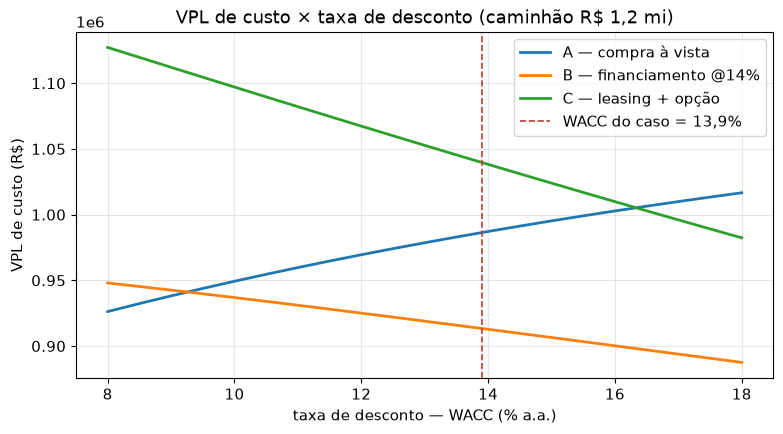

Custos @13,9%: A R$ 986.349,31 | B R$ 913.371,25 | C R$ 1.039.698,49


In [9]:
# Sensibilidade: VPL de custo dos 3 cenários vs WACC (e vs taxa de contrato do B)
waccs = np.linspace(0.08, 0.18, 21)

def vpl_A_w(w_):
    return preco_ativo - escudo_dep * af(w_, 10)

def vpl_B_w(w_):
    i_m = (1 + w_) ** (1 / 12) - 1
    j_a = juros_por_ano.copy()          # juros do contrato @14% não mudam com o WACC
    esc_j = sum(0.34 * j_a.loc[a] / (1 + w_) ** a for a in range(1, 5))
    esc_d = sum(escudo_dep / (1 + w_) ** a for a in range(1, 11))
    return entrada + parcela_fin * af(i_m, 48) - esc_j - esc_d

def vpl_C_w(w_):
    i_m = (1 + w_) ** (1 / 12) - 1
    esc_d = sum(0.34 * dep_anual / (1 + w_) ** a for a in range(4, 11))
    return parcela_leas * af(i_m, 36) + opcao / (1 + i_m) ** 36            - 0.34 * parcela_leas * af(i_m, 36) - esc_d

fig, ax = plt.subplots()
ax.plot(waccs * 100, [vpl_A_w(w_) for w_ in waccs], lw=2, label="A — compra à vista")
ax.plot(waccs * 100, [vpl_B_w(w_) for w_ in waccs], lw=2, label="B — financiamento @14%")
ax.plot(waccs * 100, [vpl_C_w(w_) for w_ in waccs], lw=2, label="C — leasing + opção")
ax.axvline(13.9, color="#c0392b", ls="--", lw=1.2, label="WACC do caso = 13,9%")
ax.set_title("VPL de custo × taxa de desconto (caminhão R$ 1,2 mi)")
ax.set_xlabel("taxa de desconto — WACC (% a.a.)")
ax.set_ylabel("VPL de custo (R$)")
ax.legend()
plt.show()

print(f"Custos @13,9%: A {brl(vpl_A)} | B {brl(vpl_B)} | C {brl(vpl_C)}")

In [10]:
# Break-even: a taxa de CONTRATO que empata o financiamento com a compra à vista
lo, hi = 0.001, 1.50                 # bisseção sobre a taxa anual do contrato
for _ in range(200):
    mid = (lo + hi) / 2
    if vpl_custo_fin(mid) - vpl_A > 0:
        hi = mid                     # contrato caro → financia pior que à vista
    else:
        lo = mid
break_even = (lo + hi) / 2

print(f"Break-even da taxa de contrato: {break_even:.2%} a.a.")
print(f"  → abaixo disso (pós-IR ~ {break_even * (1 - ir):.2%}), financiar vence a compra à vista")
print(f"  → o contrato do caso (14%) está {break_even - i_contrato_aa:.1%} abaixo do break-even")
print(f"  → checagem: custo B @21% = {brl(vpl_custo_fin(break_even))} vs custo A = {brl(vpl_A)}")

Break-even da taxa de contrato: 20.99% a.a.
  → abaixo disso (pós-IR ~ 13.86%), financiar vence a compra à vista
  → o contrato do caso (14%) está 7.0% abaixo do break-even
  → checagem: custo B @21% = R$ 986.349,31 vs custo A = R$ 986.349,31


**Break-even ≈ 21% a.a.** de contrato (≈ 13,9% pós-imposto — quando a dívida
pós-IR custa exatamente o WACC, tanto faz). O crédito rural a 14% está confortavelmente
abaixo; por isso B vence. Se o banco subir para 24%, a ordem inverte e a compra à vista
volta a ser melhor — é essa régua, e não o "juro do mês", que o relatório deve mostrar.

## 7. CAE: o empate-técnico quando os horizontes diferem

O leasing, aqui, foi "esticado" até 10 anos via opção de compra — por isso a
comparação direta de VPL é justa. Mas na vida real os prazos nem sempre batem
(36 meses × 48 meses × à vista). O remédio é o **Custo Anual Equivalente**:

$$CAE = VPL\_custo \times \frac{i}{1-(1+i)^{-n}}$$

Multiplicamos o VPL pelo fator de recuperação de capital (CRF) de 10 anos: quanto
custa "alugar" essa decisão por ano, em valor constante. CAE menor vence.

In [11]:
# CAE dos três cenários — horizonte-padrão de 10 anos
crf = 1 / af(t, 10)                  # fator de recuperação de capital
resumo_cae = pd.DataFrame({
    "cenario": ["A — Compra à vista", "B — Financiamento", "C — Leasing + opção"],
    "vpl_custo": [vpl_A, vpl_B, vpl_C],
    "cae_10anos": [vpl_A * crf, vpl_B * crf, vpl_C * crf],
})
resumo_cae["vpl_custo"] = resumo_cae["vpl_custo"].map(brl)
resumo_cae["cae_10anos"] = resumo_cae["cae_10anos"].map(brl)
resumo_cae

,cenario,vpl_custo,cae_10anos
0,A — Compra à vista,"R$ 986.349,31","R$ 188.359,11"
1,B — Financiamento,"R$ 913.371,25","R$ 174.422,78"
2,C — Leasing + opção,"R$ 1.039.698,49","R$ 198.546,98"


## 📝 Exercícios

Tente **antes** de olhar a solução. O gabarito comentado está na apostila (Seção 7).

### Exercício 1 — O leasing que o vendedor "melhora"

O vendedor do leasing volta com parcela de **R$ 32.000** (mesmo prazo de 36 meses,
mesma opção de R$ 700 mil). Recalcule o VPL de custo do cenário C e diga se o leasing
passa a vencer a compra à vista (A) e o financiamento (B).

*Ferramentas:* copie o bloco do cenário C e mude `parcela_leas`.

In [12]:
# EXERCÍCIO 1 — seu código aqui


In [13]:
# SOLUÇÃO 1 — mesmo modelo, nova parcela
p_nova = 32_000
pv_parc_ex = p_nova * af(i_wacc_m, 36)
pv_opcao_ex = opcao / (1 + i_wacc_m) ** 36
esc_ex = 0.34 * p_nova * af(i_wacc_m, 36)
esc_dep_ex = sum(0.34 * dep_anual / (1 + t) ** a for a in range(4, 11))
vpl_C_ex = pv_parc_ex + pv_opcao_ex - esc_ex - esc_dep_ex

print(f"VPL de custo — leasing a R$ 32.000/mês: {brl(vpl_C_ex)}")
print(f"  vs compra à vista (A): {brl(vpl_A)}  vs financiamento (B): {brl(vpl_B)}")
print("Continua em 3º lugar: parcela menor não vence o VPL do financiamento." )

VPL de custo — leasing a R$ 32.000/mês: R$ 981.006,33
  vs compra à vista (A): R$ 986.349,31  vs financiamento (B): R$ 913.371,25
Continua em 3º lugar: parcela menor não vence o VPL do financiamento.


**R$ 1.030.493,38 — continua em 3º.** O corte de R$ 3.000/mês melhora o leasing em
~R$ 58.700 de VPL, mas não fecha a diferença de R$ 44 mil que o separava do cenário A.
Lição: "parcela menor" vence o argumento emocional, não o VPL.

### Exercício 2 — A opção de compra que assusta

E se a opção de compra subir para **R$ 800 mil** no mês 36 (mesma parcela de R$ 35 mil)?
Recalcule o cenário C. Quanto o VPL piora e quem vence agora?

In [14]:
# EXERCÍCIO 2 — seu código aqui


In [15]:
# SOLUÇÃO 2 — opção mais cara encarece o final do fluxo
opcao_nova = 800_000
pv_opcao_n = opcao_nova / (1 + i_wacc_m) ** 36
vpl_C_n = pv_parcelas_C + pv_opcao_n - esc_leas - pv_esc_dep_C

print(f"PV da nova opção: {brl(pv_opcao_n)} (antes: {brl(pv_opcao)})")
print(f"VPL de custo — leasing com opção de R$ 800 mil: {brl(vpl_C_n)}")
print(f"Piora de {brl(vpl_C_n - vpl_C)} em valor de hoje.")

PV da nova opção: R$ 541.400,70 (antes: R$ 473.725,61)
VPL de custo — leasing com opção de R$ 800 mil: R$ 1.107.373,57
Piora de R$ 67.675,09 em valor de hoje.


**VPL de custo sobe para R$ 1.156.860,63** (+R$ 67.675 em valor de hoje). O leasing
fica ainda mais caro — e o cliente deve negociar a **opção**, que pesa quase tanto
quanto as parcelas no VPL. Em contrato real, opção alta = arrendador embutindo juros.

### Exercício 3 — O banco rival

Outro banco oferece o mesmo financiamento (entrada 20%, 48×) a **16% a.a.** Recalcule
o VPL de custo do cenário B com essa taxa de contrato. O financiamento ainda vence a
compra à vista? Quanto perdemos de escudo fiscal com o juro maior?

In [16]:
# EXERCÍCIO 3 — seu código aqui


In [17]:
# SOLUÇÃO 3 — nova taxa de contrato, novo preço do dinheiro do banco
i_16 = (1 + 0.16) ** (1 / 12) - 1
parcela_16 = pmt_price(fin_pv, i_16, n_fin)

# tabela Price a 16% para achar os juros anuais
saldo = fin_pv
juros_16 = np.zeros(4)
for k in range(1, n_fin + 1):
    j = saldo * i_16
    juros_16[min((k - 1) // 12, 3)] += j
    saldo -= (parcela_16 - j)

esc_j_16 = sum(0.34 * juros_16[a - 1] / (1 + t) ** a for a in range(1, 5))
esc_d_16 = sum(escudo_dep / (1 + t) ** a for a in range(1, 11))
vpl_B_16 = entrada + parcela_16 * af(i_wacc_m, 48) - esc_j_16 - esc_d_16

print(f"Parcela a 16% a.a.: {brl(parcela_16)} (antes: {brl(parcela_fin)})")
print(f"VPL de custo — financiamento @16%: {brl(vpl_B_16)}  (vs @14%: {brl(vpl_B)})")
print(f"  vs compra à vista (A): {brl(vpl_A)}")
print("Ainda vence? ", "SIM" if vpl_B_16 < vpl_A else "NÃO",
      f"— o break-even está em ~{break_even:.0%} a.a.")

Parcela a 16% a.a.: R$ 26.685,49 (antes: R$ 25.837,68)
VPL de custo — financiamento @16%: R$ 934.168,99  (vs @14%: R$ 913.371,25)
  vs compra à vista (A): R$ 986.349,31
Ainda vence?  SIM — o break-even está em ~21% a.a.


**VPL de custo @16% = R$ 934.168,99** — o financiamento **ainda vence** (A custa
R$ 986.349,31), mas a vantagem encolhe de R$ 72.978 para R$ 52.180. O escudo fiscal
dos juros até **cresce** (juro maior → juros dedutíveis maiores), mas as parcelas
mais caras pesam mais. Perto de ~21% a.a., o jogo inverte.

### Exercício 4 — O break-even da parcela do leasing

A que **parcela mensal** (36 meses, opção de R$ 700 mil) o leasing **empata** com a
compra à vista? Encontre por **bisseção** sobre `parcela_leas` (mesmo esqueleto do
loop que achamos o break-even da taxa) e arredonde para o real mais próximo.

*Ferramentas:* escreva `vpl_custo_leas(p)` como função da parcela e bisseção entre
R$ 20.000 e R$ 50.000.

In [18]:
# EXERCÍCIO 4 — seu código aqui


In [19]:
# SOLUÇÃO 4 — bisseção sobre a parcela do leasing
def vpl_custo_leas(p_):
    """VPL de custo do leasing em função da parcela mensal (opção fixa em R$ 700 mil)."""
    pv_p = p_ * af(i_wacc_m, 36)
    esc_l = 0.34 * pv_p
    esc_d = sum(0.34 * dep_anual / (1 + t) ** a for a in range(4, 11))
    return pv_p + opcao / (1 + i_wacc_m) ** 36 - esc_l - esc_d

lo_p, hi_p = 20_000, 50_000
for _ in range(200):
    mid_p = (lo_p + hi_p) / 2
    if vpl_custo_leas(mid_p) - vpl_A > 0:
        hi_p = mid_p                 # parcela alta → leasing pior que à vista
    else:
        lo_p = mid_p
be_parcela = (lo_p + hi_p) / 2

print(f"Break-even da parcela do leasing: {brl(be_parcela)}/mês")
print(f"  → abaixo disso, leasing vence a compra à vista (custo A = {brl(vpl_A)})")
print(f"  → o contrato atual (R$ 35.000) está {brl(parcela_leas - be_parcela)}/mês acima do empate")

Break-even da parcela do leasing: R$ 32.273,10/mês
  → abaixo disso, leasing vence a compra à vista (custo A = R$ 986.349,31)
  → o contrato atual (R$ 35.000) está R$ 2.726,90/mês acima do empate


## 📌 Resumo & para casa

- **Mesmo serviço → compare custos**: menor VPL de desembolsos pós-imposto, descontados no **WACC** — nunca a parcela, nunca o total nominal.
- **Escudo fiscal é peça do fluxo**: 34% sobre depreciação (A e B), juros do financiamento (só a parte de juros) e parcela integral do leasing.
- **Financiamento venceu** porque o juro pós-IR (9,24%) ficou **abaixo do WACC** (13,9%); break-even de contrato ≈ **21% a.a.**
- **Descontar no lugar certo**: parcelas no WACC mensal (1,0905%); a taxa do contrato é do banco, não é a régua da empresa.
- **Horizontes diferentes** → **CAE** (VPL × CRF) em um horizonte-padrão.
- **Para casa**: refaça a tabela-resumo com IRPJ+CSLL de 15% (Simples não escuda igual) e explique em 5 linhas por que a ordem dos cenários muda.
- **Próxima semana (17)**: séries temporais financeiras — IPCA, Selic e câmbio como séries, não como números.

**Referências (KB):**
- `kb/01_mckinney_python_for_data_analysis/13_chapter-11-financial-and-economic-data-applications.md` — McKinney, cap. 11 (aplicações financeiras e econômicas em pandas).
- `kb/03_jansen_ml_for_algorithmic_trading/11_chapter-5-portfolio-optimization-and-performance-evaluation.md` — Jansen, cap. 5 (taxa livre de risco, custo de capital, avaliação de desempenho).